In [2]:
import os


command = f"cd openpose && bin\OpenPoseDemo.exe --image_dir ../tpose --display 0 --render_pose 0 --write_json ../tpose"
os.system(command)


0

In [3]:
import json

with open(f"tpose/tpose_keypoints.json", "r") as file:
    tpose = json.load(file)

In [7]:
frame_size = (1408, 768)

joints = []
joints_with_confidence = []

for i in range(25):
    joint = tpose['people'][0]['pose_keypoints_2d'][i*3:i*3+3]
    joint_scaled = [joint[0]/frame_size[0], joint[1]/frame_size[1]]
    joints.append(joint_scaled)
    joints_with_confidence.append(joint_scaled + [joint[2]])

print(joints)

openpose_joints = joints

[[0.5000248579545454, 0.14827734374999998], [0.5015007102272727, 0.24944531250000002], [0.4567649147727273, 0.2494830729166667], [0.38813423295454547, 0.2522421875], [0.32402911931818185, 0.24954296875], [0.5447556818181818, 0.24946875000000002], [0.6163174715909091, 0.24958854166666666], [0.6848806818181818, 0.24940625000000002], [0.5014737215909091, 0.5201966145833333], [0.4717144886363636, 0.5201497395833333], [0.47165269886363637, 0.71151953125], [0.4716818181818182, 0.8920690104166668], [0.5298018465909091, 0.5229244791666666], [0.5298061079545454, 0.7115794270833334], [0.5298678977272727, 0.8948268229166666], [0.4925681818181818, 0.13741536458333334], [0.5089232954545454, 0.13739453125], [0.48062571022727274, 0.14834505208333335], [0.5194794034090909, 0.14828125], [0.53875, 0.9357838541666667], [0.5462684659090908, 0.9302955729166666], [0.5223948863636364, 0.9085559895833333], [0.4657109375, 0.9304687500000001], [0.45676917613636364, 0.9276289062499999], [0.47765340909090903, 0.9

In [25]:
body_25_names = {
    14 : "lfoot", 
    11 : "rfoot", 
    13 : "ltibia", 
    10 : "rtibia", 
    12 : "lfemur", 
    9 : "rfemur",
    5 : "lhumerus", 
    2 : "rhumerus",
    6 : "lradius", 
    3 : "rradius",
    7 : "lwrist", 
    4 : "rwrist",
}

In [8]:
from ultralytics import YOLO

model = YOLO("yolo26x-pose.pt")

results = model("tpose/tpose.png")

for result in results:
    xyn = result.keypoints.xyn  # normalized


image 1/1 C:\Users\Miko7\Studia\magisterka\gait-features-identification\tpose\tpose.png: 352x640 1 person, 130.1ms
Speed: 5.8ms preprocess, 130.1ms inference, 32.7ms postprocess per image at shape (1, 3, 352, 640)


In [30]:
coco_joints = xyn.cpu().tolist()[0]
coco_joints

[[0.5010932087898254, 0.15050961077213287],
 [0.5097744464874268, 0.13411562144756317],
 [0.4916246235370636, 0.13552117347717285],
 [0.5211714506149292, 0.1485644280910492],
 [0.4792647361755371, 0.15013033151626587],
 [0.5488848686218262, 0.2458500862121582],
 [0.45338138937950134, 0.24768780171871185],
 [0.6154648661613464, 0.25232094526290894],
 [0.383430540561676, 0.253815621137619],
 [0.6775367259979248, 0.24094632267951965],
 [0.3226259648799896, 0.24496984481811523],
 [0.5296480655670166, 0.5195586681365967],
 [0.4728657603263855, 0.521746039390564],
 [0.5297396779060364, 0.7117771506309509],
 [0.4714491367340088, 0.7134705781936646],
 [0.5300171971321106, 0.8986759185791016],
 [0.47131824493408203, 0.8961526155471802]]

In [26]:
coco_names = {5: 'lhumerus',
 6: 'rhumerus',
 11: 'lfemur',
 12: 'rfemur',
 13: 'ltibia',
 14: 'rtibia',
 15: 'lfoot',
 16: 'rfoot',
 7: 'lradius',
 8: 'rradius',
 9: 'lwrist',
 10: 'rwrist'}

In [31]:
mediapipe_joints = [[0.5022277235984802, 0.15681910514831543],
 [0.5069358348846436, 0.1407233476638794],
 [0.5109795928001404, 0.14067742228507996],
 [0.51341712474823, 0.14053303003311157],
 [0.4963839650154114, 0.1404852271080017],
 [0.4930456280708313, 0.1407371461391449],
 [0.4898691475391388, 0.14071491360664368],
 [0.5157421827316284, 0.1470489501953125],
 [0.4842260181903839, 0.146823912858963],
 [0.5087696313858032, 0.17340275645256042],
 [0.4971288740634918, 0.17372918128967285],
 [0.5478625297546387, 0.24858519434928894],
 [0.45303916931152344, 0.24588873982429504],
 [0.6169276237487793, 0.25821614265441895],
 [0.3860727548599243, 0.2574482560157776],
 [0.6802425384521484, 0.2491927146911621],
 [0.3214572072029114, 0.25062182545661926],
 [0.6987837553024292, 0.25048398971557617],
 [0.30124467611312866, 0.2537907063961029],
 [0.7012148499488831, 0.24913081526756287],
 [0.2991991639137268, 0.24991875886917114],
 [0.6929715871810913, 0.25126776099205017],
 [0.30864131450653076, 0.25171494483947754],
 [0.5284090042114258, 0.5224979519844055],
 [0.47557535767555237, 0.5222020745277405],
 [0.5284483432769775, 0.7148033976554871],
 [0.4731336832046509, 0.7142758369445801],
 [0.5283528566360474, 0.8868896961212158],
 [0.47510674595832825, 0.8887782096862793],
 [0.5223177671432495, 0.9104599356651306],
 [0.4796648919582367, 0.9105558395385742],
 [0.533974826335907, 0.9400397539138794],
 [0.46272364258766174, 0.9420024156570435]]

In [27]:
mediapipe_names = {
    27 : "lfoot", 
    28 : "rfoot", 
    25 : "ltibia", 
    26 : "rtibia", 
    23 : "lfemur", 
    24 : "rfemur",
    11 : "lhumerus", 
    12 : "rhumerus",
    13 : "lradius", 
    14 : "rradius",
    15 : "lwrist", 
    16 : "rwrist",
}


In [127]:
import bvhio

SEQ_KEY = "p6s1"

bvh_file_path = f'gait3d/Sequences/{SEQ_KEY}/MoCap/{SEQ_KEY}.bvh'

root = bvhio.readAsHierarchy(bvh_file_path)

restPose=bvhio.Transform(scale=1)
root = bvhio.Joint('Root', restPose=bvhio.Transform(scale=1)).attach(root)

step = 4
start_frame = 0
end_frame = start_frame + 3 * step

position_bvh = [joint.PositionWorld for (joint, index, depth) in root.loadPose(start_frame).layout()]
print(position_bvh)

selected_joint_names = (["lfoot", "rfoot", 
                         "ltibia", "rtibia", 
                         "lfemur", "rfemur",
                         "lhumerus", "rhumerus",
                         "lradius", "rradius",
                         "lwrist", "rwrist",])
selected_joint_names

[vec3( 0, 0, 0 ), vec3( 0.813704, 3.87664, 0.206465 ), vec3( 0.813704, 3.87664, 0.206465 ), vec3( 0.677868, 3.72148, 0.76088 ), vec3( 0.862607, 2.06406, 0.749168 ), vec3( 1.04582, 0.420375, 0.737516 ), vec3( 0.518801, 0.225133, 0.822051 ), vec3( 0.813704, 3.87664, 0.206465 ), vec3( 0.741567, 3.72571, -0.364499 ), vec3( 0.76254, 2.02026, -0.283363 ), vec3( 0.969178, 0.460332, -0.226724 ), vec3( 0.470145, 0.212, -0.362158 ), vec3( 0.813704, 3.87664, 0.206465 ), vec3( 0.804782, 4.40305, 0.247165 ), vec3( 0.885234, 4.92121, 0.300396 ), vec3( 0.946687, 5.45069, 0.296148 ), vec3( 1.00018, 5.83548, 0.302651 ), vec3( 1.0155, 6.21947, 0.32463 ), vec3( 0.946687, 5.45069, 0.296148 ), vec3( 0.779188, 5.82993, 0.830356 ), vec3( 0.83844, 5.38845, 1.94454 ), vec3( 0.585349, 5.44832, 2.55291 ), vec3( 0.458804, 5.47826, 2.85709 ), vec3( 0.946687, 5.45069, 0.296148 ), vec3( 0.931834, 5.8446, -0.251226 ), vec3( 1.0043, 5.38992, -1.40189 ), vec3( 0.857182, 5.47352, -2.05201 ), vec3( 0.783622, 5.51533, -2.

['lfoot',
 'rfoot',
 'ltibia',
 'rtibia',
 'lfemur',
 'rfemur',
 'lhumerus',
 'rhumerus',
 'lradius',
 'rradius',
 'lwrist',
 'rwrist']

In [128]:
mocap_names = {}
mocap_joints = []

for (joint, index, depth) in root.layout():
    print(f'{position_bvh[index]} {joint.Name}')
    
for i, (joint, index, depth) in enumerate(root.layout()):
    mocap_joints.append([position_bvh[index][2], -position_bvh[index][1]])
    if joint.Name in selected_joint_names:
        mocap_names[i] = joint.Name

mocap_names

vec3(            0,            0,            0 ) Root
vec3(     0.813704,      3.87664,     0.206465 ) root
vec3(     0.813704,      3.87664,     0.206465 ) lhipjoint
vec3(     0.677868,      3.72148,      0.76088 ) lfemur
vec3(     0.862607,      2.06406,     0.749168 ) ltibia
vec3(      1.04582,     0.420375,     0.737516 ) lfoot
vec3(     0.518801,     0.225133,     0.822051 ) ltoes
vec3(     0.813704,      3.87664,     0.206465 ) rhipjoint
vec3(     0.741567,      3.72571,    -0.364499 ) rfemur
vec3(      0.76254,      2.02026,    -0.283363 ) rtibia
vec3(     0.969178,     0.460332,    -0.226724 ) rfoot
vec3(     0.470145,        0.212,    -0.362158 ) rtoes
vec3(     0.813704,      3.87664,     0.206465 ) lowerback
vec3(     0.804782,      4.40305,     0.247165 ) upperback
vec3(     0.885234,      4.92121,     0.300396 ) thorax
vec3(     0.946687,      5.45069,     0.296148 ) lowerneck
vec3(      1.00018,      5.83548,     0.302651 ) upperneck
vec3(       1.0155,      6.21947,     

{3: 'lfemur',
 4: 'ltibia',
 5: 'lfoot',
 8: 'rfemur',
 9: 'rtibia',
 10: 'rfoot',
 19: 'lhumerus',
 20: 'lradius',
 21: 'lwrist',
 24: 'rhumerus',
 25: 'rradius',
 26: 'rwrist'}

In [141]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_points(datasets, important_indices, titles):   
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    
    for i, data in enumerate(datasets):
        data_np = np.array(data)
        
        mask = np.zeros(len(data_np), dtype=bool)
        mask[list(important_indices[i].keys())] = True
        
        normal_points = data_np[~mask]
        important_points = data_np[mask]
        
        axes[i].scatter(normal_points[:, 0], normal_points[:, 1], 
                        c='black', s=33, label='Not selected')
        
        axes[i].scatter(important_points[:, 0], important_points[:, 1], 
                        c='crimson', s=75, label='Selected', edgecolors='black')

        axes[i].invert_xaxis()
        axes[i].invert_yaxis()
        
        axes[i].set_xticks([]) 
        axes[i].set_yticks([])
        
        axes[i].set_title(titles[i])
        axes[i].legend(loc='center left', frameon=True)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("plots/selected_joints.pdf", format="pdf")  
    plt.show()

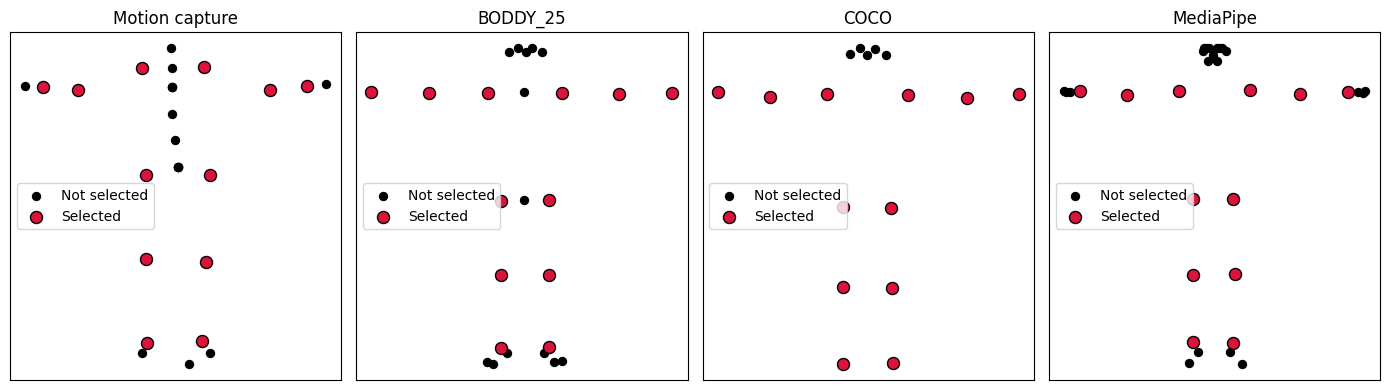

In [142]:
datasets = [mocap_joints, openpose_joints, coco_joints, mediapipe_joints]
important_indices = [mocap_names, body_25_names, coco_names, mediapipe_names]
titles = ["Motion capture", "BODDY_25", "COCO", "MediaPipe"]

visualize_points(datasets, important_indices, titles)